# HW3 - Neural Network for USPS Digit Classification

**Dohyeong Ryu**

A fully-connected Neural Network (MLP) is trained on the USPS handwritten digit dataset
and evaluated with **5-fold stratified cross-validation**.

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

SEED       = 42
N_FOLDS    = 5
EPOCHS     = 60
BATCH_SIZE = 128
LR         = 1e-3
WEIGHT_DECAY = 1e-4

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
device = torch.device('cpu')   # small model -> CPU is fast and fully reproducible
print('PyTorch', torch.__version__, '| device:', device)

PyTorch 2.12.1 | device: cpu


## 1. Dataset: USPS Digits

- Grayscale **16×16** images, flattened to **256 features**, pixel values in [-1, 1]
- **10 classes** (digits 0-9), **9,298 samples** in total
- Loaded from OpenML; the raw labels are 1-10, so they are remapped to digits 0-9 (`digit = label - 1`)

In [2]:
usps = fetch_openml('usps', version=1)
X, y = usps['data'], usps['target'].astype(int)

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y) - 1            # labels 1..10 -> digits 0..9

print('X:', X.shape, '| pixel range: [%.1f, %.1f]' % (X.min(), X.max()))
print('y:', y.shape, '| classes:', np.unique(y))
print('samples per class:', np.bincount(y))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/datasets/_openml.py:1030: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


X: (9298, 256) | pixel range: [-1.0, 1.0]
y: (9298,) | classes: [0 1 2 3 4 5 6 7 8 9]
samples per class: [1553 1269  929  824  852  716  834  792  708  821]


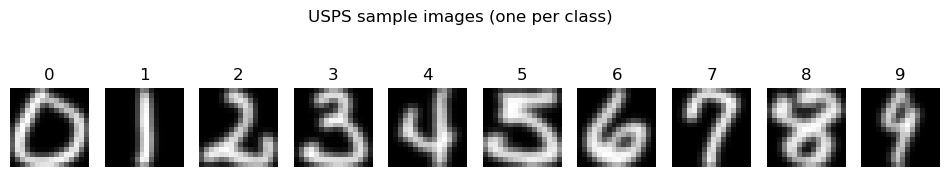

In [3]:
# One sample image per digit -- visually confirms the label remapping is correct
fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for d, ax in enumerate(axes):
    idx = np.where(y == d)[0][0]
    ax.imshow(X[idx].reshape(16, 16), cmap='gray')
    ax.set_title(str(d))
    ax.axis('off')
plt.suptitle('USPS sample images (one per class)', y=1.15)
plt.savefig('fig1_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Network Architecture

| | |
|---|---|
| **Layers / nodes** | Input **256** → Hidden 1: **256** → Hidden 2: **128** → Output: **10** |
| **Activations** | **ReLU** on both hidden layers; the output layer is linear (softmax is applied inside the loss) |
| **Regularization** | **Dropout p = 0.3** after each hidden layer + **L2 weight decay = 1e-4** |
| **Loss function** | **Cross-Entropy loss** (standard for multi-class classification) |
| **Optimizer** | **Adam**, learning rate **1e-3** |
| **Training strategy** | Mini-batch SGD (batch size **128**) for **60 epochs** per fold; features standardized with `StandardScaler` fitted **on the training folds only** (no data leakage); fixed random seeds for reproducibility |

**Why this design?** The images are small (256-d vectors), so a two-hidden-layer MLP has enough
capacity for this task. ReLU avoids vanishing gradients, Adam converges quickly without manual
learning-rate tuning, and Dropout + weight decay control overfitting. The learning curves below
confirm that 60 epochs are sufficient for convergence.

In [4]:
class MLP(nn.Module):
    def __init__(self, n_in=256, n_h1=256, n_h2=128, n_out=10, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, n_h1), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(n_h1, n_h2), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(n_h2, n_out),
        )

    def forward(self, x):
        return self.net(x)

MLP()

MLP(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [5]:
def run_fold(X_train, y_train, X_val, y_val, seed):
    """Train one model on one fold; return per-epoch history + final val accuracy."""
    set_seed(seed)
    model = MLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    train_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
    loader = torch.utils.data.DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(seed))

    X_val_t = torch.tensor(X_val).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(EPOCHS):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(xb)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += len(xb)

        model.eval()
        with torch.no_grad():
            val_out  = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            val_acc  = (val_out.argmax(1) == y_val_t).float().mean().item()

        hist['train_loss'].append(loss_sum / total)
        hist['train_acc'].append(correct / total)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)

    return hist, hist['val_acc'][-1]

## 3. 5-Fold Stratified Cross-Validation

`StratifiedKFold` splits the 9,298 samples into 5 folds while preserving the class
proportions in every fold. Each experiment trains a **fresh** model on 4 folds (~7,438 samples)
and evaluates on the held-out fold (~1,860 samples), so every sample is used for validation
exactly once.

In [6]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

histories, accuracies = [], []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    scaler = StandardScaler().fit(X[tr_idx])            # fit on training folds only
    X_tr, X_va = scaler.transform(X[tr_idx]), scaler.transform(X[va_idx])

    hist, acc = run_fold(X_tr.astype(np.float32), y[tr_idx],
                         X_va.astype(np.float32), y[va_idx], seed=SEED + fold)
    histories.append(hist)
    accuracies.append(acc)
    print(f'Experiment {fold}: train {len(tr_idx)} / val {len(va_idx)} samples '
          f'-> validation accuracy = {acc:.4f}')

print(f'\nAverage accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}')

Experiment 1: train 7438 / val 1860 samples -> validation accuracy = 0.9785


Experiment 2: train 7438 / val 1860 samples -> validation accuracy = 0.9769


Experiment 3: train 7438 / val 1860 samples -> validation accuracy = 0.9790


Experiment 4: train 7439 / val 1859 samples -> validation accuracy = 0.9731


Experiment 5: train 7439 / val 1859 samples -> validation accuracy = 0.9715

Average accuracy: 0.9758 ± 0.0030


## 4. Learning Curves

For every fold, the training/validation **loss** (left) and **accuracy** (right) are plotted
per epoch. Both losses decrease smoothly and plateau well before epoch 60, and the validation
accuracy stabilizes without diverging from the training accuracy — the models are properly
trained and have converged, with no sign of severe overfitting.

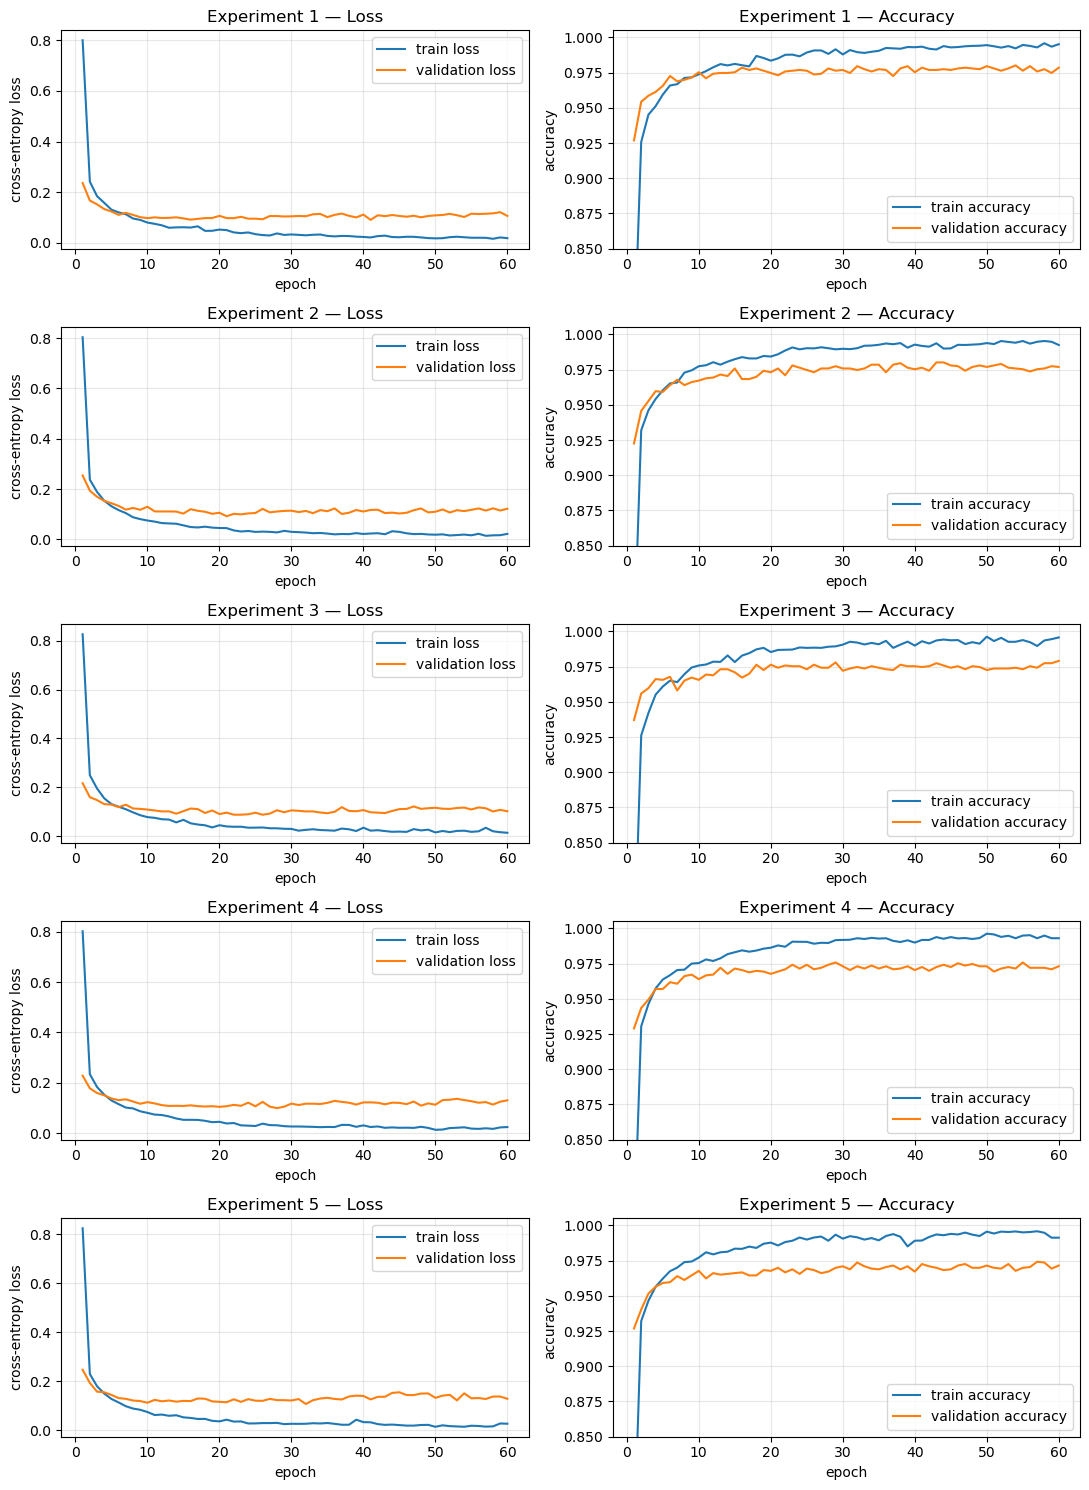

In [7]:
fig, axes = plt.subplots(N_FOLDS, 2, figsize=(11, 3.0 * N_FOLDS))
epochs_x = np.arange(1, EPOCHS + 1)

for f, hist in enumerate(histories):
    ax = axes[f, 0]
    ax.plot(epochs_x, hist['train_loss'], label='train loss')
    ax.plot(epochs_x, hist['val_loss'],   label='validation loss')
    ax.set_title(f'Experiment {f+1} — Loss')
    ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy loss')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[f, 1]
    ax.plot(epochs_x, hist['train_acc'], label='train accuracy')
    ax.plot(epochs_x, hist['val_acc'],   label='validation accuracy')
    ax.set_title(f'Experiment {f+1} — Accuracy')
    ax.set_xlabel('epoch'); ax.set_ylabel('accuracy')
    ax.set_ylim(0.85, 1.005)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Results

In [8]:
rows = [[f'{acc:.4f}'] for acc in accuracies]
rows.append([f'{np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}'])

results = pd.DataFrame(
    rows, columns=['Accuracy'],
    index=[f'Experiment {i+1}' for i in range(N_FOLDS)] + ['Average'])
results.index.name = 'Neural Network'
results.to_csv('results.csv')
results

,Accuracy
Neural Network,
Experiment 1,0.9785
Experiment 2,0.9769
Experiment 3,0.9790
Experiment 4,0.9731
Experiment 5,0.9715
Average,0.9758 ± 0.0030


## 6. Conclusion

The two-hidden-layer MLP (256-256-128-10, ReLU, Dropout) trained with Adam and cross-entropy
loss classifies USPS digits with an average accuracy of **97.58% ± 0.30%** under 5-fold stratified
cross-validation, with very low variance across folds. The learning curves show smooth
convergence within 60 epochs, confirming a properly trained model.